# **1. Load and Understand Data**

Import Libraries that are used in the analysis process

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Analysis statement : 

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this project, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

1. Do more restaurants provide online delivery compared to offline services?
2. Which types of restaurants are most favored by the general public?
3. What price range do couples prefer for dining out?

Before proceeding we must load the dataset and understand the dataset.


1. How many rows are there?

In [2]:
dataframe=pd.read_csv('Zomato-data-.csv')
dataframe.shape #no. of rows and columns

(148, 7)

2. How many columns are there?

In [3]:
len(dataframe.columns) 
# number of columns

7

3. What does each column represent?

In [4]:
dataframe.columns # Lists all column names so you know what information is available.

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

4. Are there missing values?

In [5]:
dataframe.info() #Shows whether any column has missing (null) values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [6]:
dataframe.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

5. What data types are present?

In [7]:
dataframe.dtypes #Displays whether columns are integers, floats, strings, booleans, etc.

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

6. What does the data look like?

In [8]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [9]:
dataframe.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


7.What statistics can we derive immediately?

In [10]:
dataframe.describe() #Gives summary statistics like count, mean, standard deviation, minimum, maximum, and quartiles for numerical columns.

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


Conclusions after Exploratory data Analysis - Initial Data Inspection :

1. There ar 148 rows and 7 columns in the dataset
2. The columns are : 'name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'
3. There are no missing values
4. The datatypes included in this statement are object type and int64
5. The dataset contains information about the restaurant name, online ordering availability, booking table,ratings, votes, approximate cost for two people and the restaurant type
6. The avaerage number of vote is 264.8 and avaerage cost for 2 people is 418.25

# **2. Data Cleaning**

In [11]:
dataframe.isnull() #isnull()

# Checks every cell in the DataFrame.

# If a value is missing, it returns True.

# If a value exists, it returns False.

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
143,False,False,False,False,False,False,False
144,False,False,False,False,False,False,False
145,False,False,False,False,False,False,False
146,False,False,False,False,False,False,False


In [12]:
dataframe.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

If duplicates exist we must remove duplicates

In [13]:
dataframe.duplicated() #It checks whether a row has already appeared earlier in the dataset.

0      False
1      False
2      False
3      False
4      False
       ...  
143    False
144    False
145    False
146    False
147    False
Length: 148, dtype: bool

In [14]:
dataframe.duplicated().sum()

0

In [15]:
dataframe.drop_duplicates(inplace=True)

# **Check Data Types**

In [16]:
dataframe['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [17]:
dataframe['rate']=dataframe['rate'].str.replace('/5','',regex=False)

In [18]:
#strip() removes spaces from the beginning and end of a string.

In [19]:
dataframe['rate']=dataframe['rate'].str.strip()
dataframe['rate']=dataframe['rate'].astype(float)
# def handlerate(value):
#     value=str(value).split('/')
#     value=value[0]
#     return float(value)
# dataframe['rate']=dataframe['rate'].apply(handlerate)

In [20]:
dataframe['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4])

In [21]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 9.2+ KB


I learned : 
1. Inspecting unique values with unique()
2. Removing unwanted text using str.replace()
3. Removing extra spaces using str.strip()
4. Converting a column from text to numbers using astype(float)
5. Verifying changes with info()

Checking for Inconsistent Values for Categorical values

unique() helps us:

* Find spelling mistakes
* Detect inconsistent capitalization
* Find unexpected values
* Understand all categories in a column

In [22]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [23]:
dataframe['online_order'].unique()

array(['Yes', 'No'], dtype=object)

In [24]:
dataframe['book_table'].unique()

array(['Yes', 'No'], dtype=object)

In [25]:
dataframe['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'other', 'Dining'], dtype=object)

Conclusion :
* Checked for missing values
* Checked for duplicate rows
* Inspected data types
* Cleaned the rate column
* Converted rate to float
* Verified categorical values

# **Exploratory Data Analysis**

1. What type of restaurants are most common?

In [26]:
dataframe['listed_in(type)'].value_counts()

Dining    110
Cafes      23
other       8
Buffet      7
Name: listed_in(type), dtype: int64

In [27]:
counts = dataframe['listed_in(type)'].value_counts()
counts

Dining    110
Cafes      23
other       8
Buffet      7
Name: listed_in(type), dtype: int64

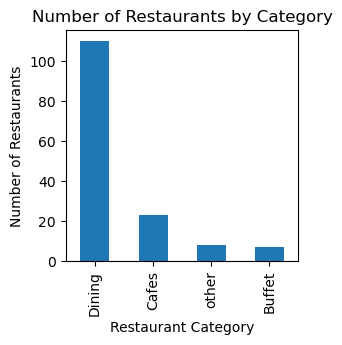

In [28]:
plt.figure(figsize=(3,3))
counts.plot(kind='bar')

plt.title("Number of Restaurants by Category")
plt.xlabel("Restaurant Category")
plt.ylabel("Number of Restaurants")

plt.show()

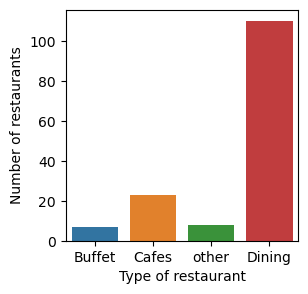

In [29]:
# sns.countplot(x="listed_in(type)",data=dataframe)
plt.figure(figsize=(3,3))

sns.countplot(x=dataframe["listed_in(type)"])
plt.xlabel("Type of restaurant")
plt.ylabel("Number of restaurants")
plt.show()

Conclusion : Dining restaurants dominate the dataset with 110 restaurants, indicating they are the most popular business category. Buffet restaurants are the least represented, with only 7 restaurants.

2. Which type of restaurant receives the most customer votes?

In [30]:
dataframe.head(2)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet


In [31]:
grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
grouped_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

Conclusion : 
Dining restaurants have the highest number of customer votes(20,363), suggesting that they are the most visited and most actively reviewed restaurant category in the dataset.

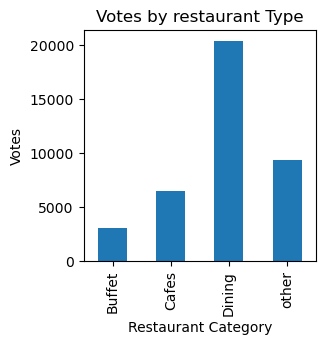

In [32]:
plt.figure(figsize=(3,3))

grouped_data.plot(kind='bar')
plt.title('Votes by restaurant Type')
plt.xlabel('Restaurant Category')
plt.ylabel('Votes')
plt.show()

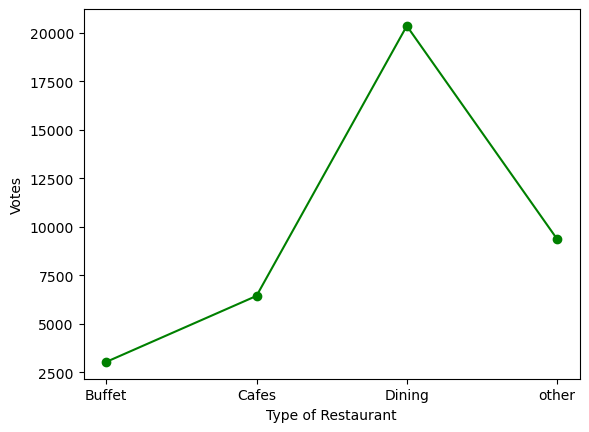

In [33]:
grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of Restaurant')
plt.ylabel('Votes')
plt.show()

Business Insights : Dining restaurants receive highest number of customer votes(20363) indicating more customer engagement in the datase. Buffest restaurants receives lowest votes suggesting they are least popular or least represented category

3. Find the restaurant with the highest number of votes.

In [34]:
dataframe.loc[dataframe['votes'].idxmax()]

name                           Empire Restaurant
online_order                                 Yes
book_table                                    No
rate                                         4.4
votes                                       4884
approx_cost(for two people)                  750
listed_in(type)                            other
Name: 38, dtype: object

In [35]:
dataframe.loc[dataframe['votes'].idxmax(),['name','votes']]
# idxmax() directly finds the index of the maximum value without sorting the whole dataset. It's simpler and often more efficient when I only need the row with the highest value

name     Empire Restaurant
votes                 4884
Name: 38, dtype: object

Business insights : 

Empire restaurant has the highest customer engagement and is popular. It has 4884 votes, that indicates it has frequestly reviewed restaurant in the dataset.

In [36]:
dataframe.sort_values(by='votes', ascending=False).head(5) #top 5 restaurants

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,Yes,No,4.4,4884,750,other
86,Meghana Foods,Yes,No,4.4,4401,600,Dining
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
44,Onesta,Yes,Yes,4.6,2556,600,other
65,Kabab Magic,Yes,No,4.1,1720,400,Dining


4. How many restaurants accept online orders?

In [37]:
online_counts=dataframe['online_order'].value_counts()
online_counts

No     90
Yes    58
Name: online_order, dtype: int64

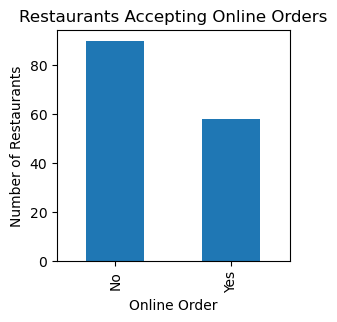

In [38]:
plt.figure(figsize=(3,3))
online_counts.plot(kind='bar')
plt.title("Restaurants Accepting Online Orders")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")
plt.show()

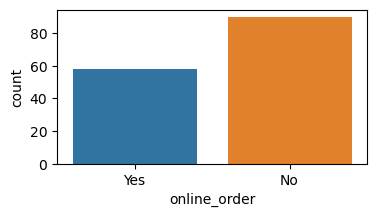

In [39]:
plt.figure(figsize=(4,2))
sns.countplot(x='online_order',data=dataframe)
plt.show()

In [40]:
90/148*100

60.810810810810814

In [41]:
58/148*100

39.189189189189186

Business Insights: Most of the restaurants in the dataset do not accept online orders(90 of 148 ~ 61%) and only 58 restaurants accept online orders(~39%), indicating offline dining is more common in this dataset

5. Do restaurants that accept online orders have higher ratings than those that don't?


In [42]:
rate_mean=dataframe.groupby('online_order')['rate'].mean()
rate_mean

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64

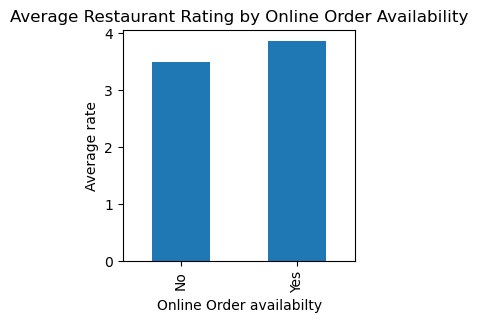

In [43]:
plt.figure(figsize=(3,3))
rate_mean.plot(kind='bar')
plt.title("Average Restaurant Rating by Online Order Availability")
plt.xlabel("Online Order availabilty")
plt.ylabel("Average rate")
plt.show()

Business insights : The average ratings of the restaurants accepting online order is more than the restaurants not accepting online order in this dataset.This indicates that restaurants providing online ordering tend to receive better customer ratings in this dataset.

6. How are the restaurant ratings distributed?

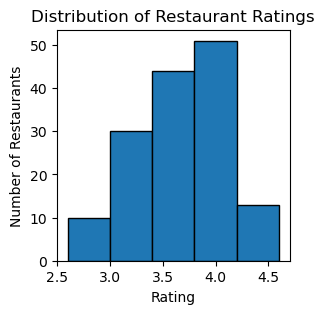

In [48]:
plt.figure(figsize=(3,3))
plt.hist(dataframe['rate'],bins=5,edgecolor='black')
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

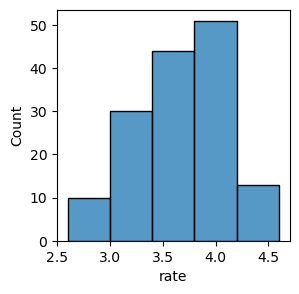

In [50]:
plt.figure(figsize=(3,3))
sns.histplot(x='rate',data=dataframe,bins=5)
plt.show()

Business Insight: Most restaurants have ratings between 3.5 and 4.2, indicating that the majority of restaurants in the dataset are well-rated by customers. Very few restaurants have ratings below 3.0, suggesting that poorly rated restaurants are relatively uncommon.

7. Analyze the approx_cost(for two people) column to find the preferred price range.

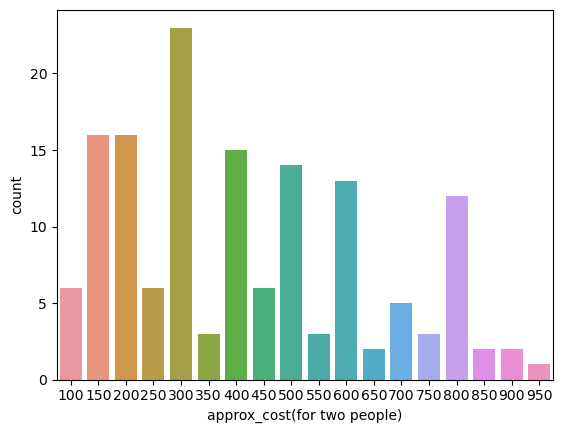

In [55]:
sns.countplot(x=dataframe['approx_cost(for two people)'])
plt.show()

In [56]:
dataframe['approx_cost(for two people)'].unique()

array([800, 300, 600, 700, 550, 500, 450, 650, 400, 900, 200, 750, 150,
       850, 100, 350, 250, 950], dtype=int64)

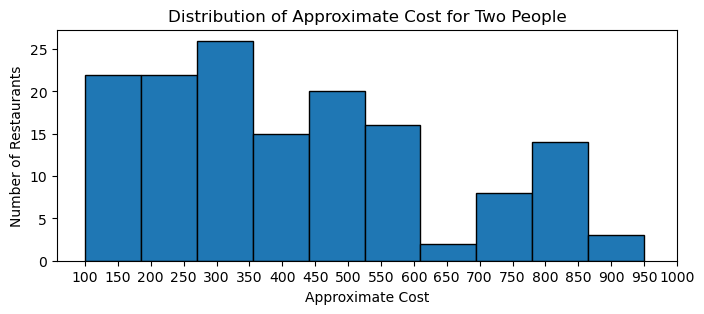

In [65]:
plt.figure(figsize=(8,3))

plt.hist(dataframe['approx_cost(for two people)'], bins=10, edgecolor='black')
plt.xticks(range(100,1001,50))
plt.title("Distribution of Approximate Cost for Two People")
plt.xlabel("Approximate Cost")
plt.ylabel("Number of Restaurants")

plt.show()

Business Insight: The majority of restaurants are concentrated within the ₹100–₹550 price range, suggesting that the dataset is largely composed of budget-friendly and mid-range dining options. The greatest concentration of restaurants falls in the ₹250–₹350 range, whereas restaurants with approximate costs above ₹700 are comparatively fewer.

8. Compare ratings between restaurants that accept online orders and those that don't.






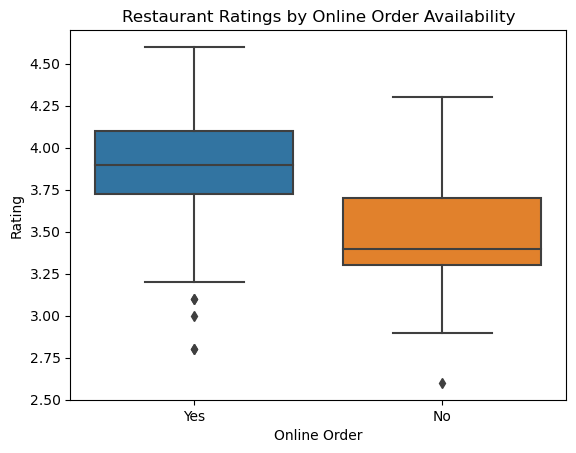

In [67]:
sns.boxplot(x='online_order',y='rate',data=dataframe)
plt.title("Restaurant Ratings by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.show()

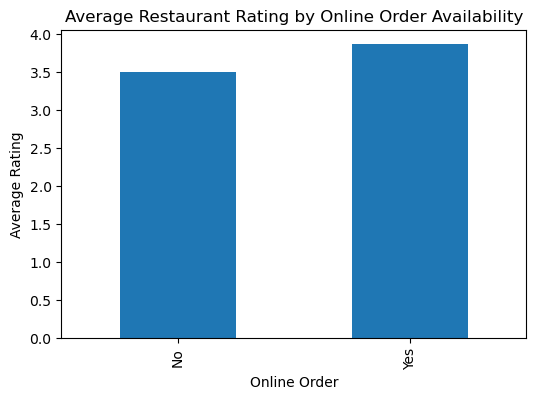

In [69]:
rate_mean = dataframe.groupby('online_order')['rate'].mean()
plt.figure(figsize=(6,4))

rate_mean.plot(kind='bar')

plt.title("Average Restaurant Rating by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Average Rating")

plt.show() #The average rating of restaurants accepting online orders is higher.

Business Insight: Restaurants that offer online ordering have a higher average customer rating (3.86) compared to restaurants that do not offer online ordering (3.49). This indicates a positive association between online ordering availability and customer ratings in this dataset. However, this analysis shows a relationship and does not imply that online ordering alone is responsible for higher ratings, as other factors such as food quality, service, location, and restaurant popularity may also influence customer ratings.

9. Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).

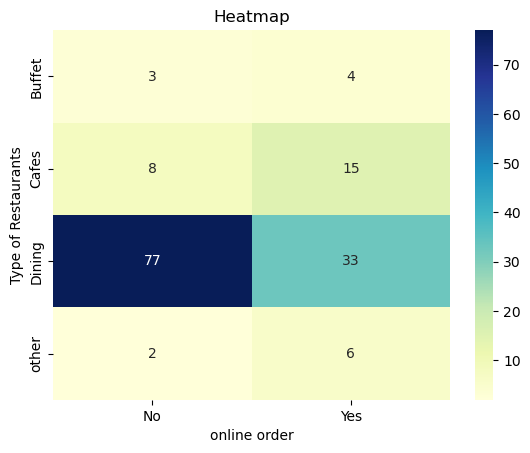

In [70]:
pivot_table=dataframe.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Heatmap')
plt.xlabel('online order')
plt.ylabel('Type of Restaurants')
plt.show()

In [74]:
33/(77+33)*100, 15/23*100

(30.0, 65.21739130434783)

Business Insight: Dining restaurants constitute the largest restaurant category in the dataset and therefore account for the highest number of restaurants with and without online ordering. However, Cafes exhibit a higher proportion of restaurants offering online ordering, indicating that online ordering is relatively more common among Cafes than Dining restaurants. Buffet restaurants are the least represented category across both order modes.

10. How many restaurants provide table booking?

In [77]:
dataframe.head(2)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet


In [78]:
dataframe['book_table'].value_counts()

No     140
Yes      8
Name: book_table, dtype: int64

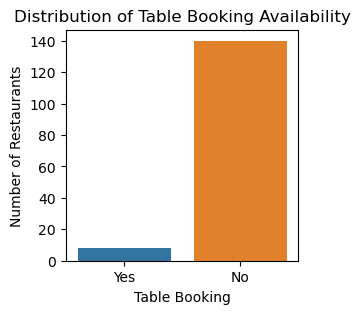

In [81]:
plt.figure(figsize=(3,3))
sns.countplot(x='book_table',data=dataframe)
plt.title("Distribution of Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")
plt.show()

In [82]:
8/148*100

5.405405405405405

Business Insight: The majority of restaurants in the dataset (140 out of 148) do not provide table booking facilities, while only approximately 5% offer this service. This indicates that table booking is relatively uncommon among the restaurants in the dataset. However, further customer demand analysis would be required before concluding whether expanding table booking services would be beneficial.

11. Do restaurants that offer table booking receive higher customer ratings?

In [86]:
rate_grouped_data=dataframe.groupby('book_table')['rate'].mean()
rate_grouped_data

book_table
No     3.601429
Yes    4.187500
Name: rate, dtype: float64

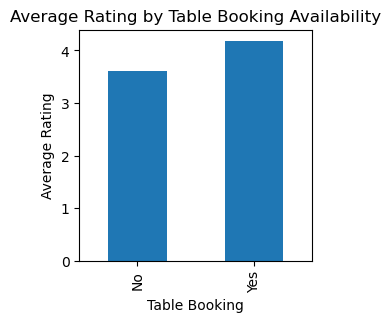

In [92]:
plt.figure(figsize=(3,3))
rate_grouped_data.plot(kind='bar')
plt.title("Average Rating by Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")
plt.show()

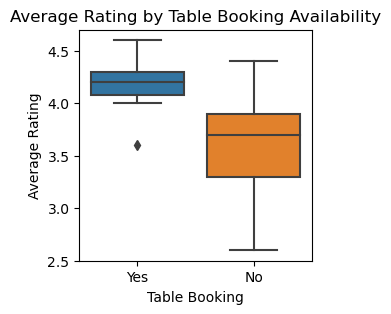

In [96]:
plt.figure(figsize=(3,3))
sns.boxplot(x="book_table",y="rate",data=dataframe)
plt.title("Average Rating by Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")
plt.show()

Business Insight: Restaurants that provide table booking generally receive higher customer ratings than those that do not. Additionally, the ratings of restaurants with table booking are more consistent, as indicated by the smaller spread in the box plot. In contrast, restaurants without table booking exhibit greater variability in their ratings, suggesting a wider range of customer experiences.

# **Key Findings**

1. Dining restaurants are the most common restaurant type in the dataset.
2. Dining restaurants receive the highest total customer votes.
3. Restaurants offering online ordering have higher average customer ratings.
4. Most restaurants fall within the ₹100–₹550 price range for two people.
5. Table booking facilities are uncommon, with only about 5% of restaurants offering them.
6. Restaurants providing table booking generally exhibit higher and more consistent customer ratings.

# **Business Recommendations**

1. Restaurants may consider improving their online ordering services, as restaurants offering online ordering tend to receive higher customer ratings.
2. Restaurant owners should further investigate customer demand for table booking before implementing reservation systems.
3. New restaurants targeting the mid-range pricing segment (₹200–₹500) may align well with the dominant market segment represented in the dataset.

# **Project Conclusion**

This exploratory data analysis examined restaurant characteristics, customer ratings, pricing, online ordering, and table booking availability using the Zomato dataset. The analysis identified patterns in restaurant categories, customer preferences, and service offerings through statistical summaries and visualizations. These insights can help restaurant owners understand market trends and identify potential areas for service improvement. Further analysis using larger datasets and predictive machine learning models could provide deeper insights into the factors influencing restaurant ratings and customer engagement.